In [1]:
import numpy as np
from scipy import fft, signal
import scipy as sp
from matplotlib import pyplot as plt
import matplotlib.animation

from IPython.display import HTML, Image

%config InlineBackend.figure_formats = ['svg']

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.RenderedHTMLCommon{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

 


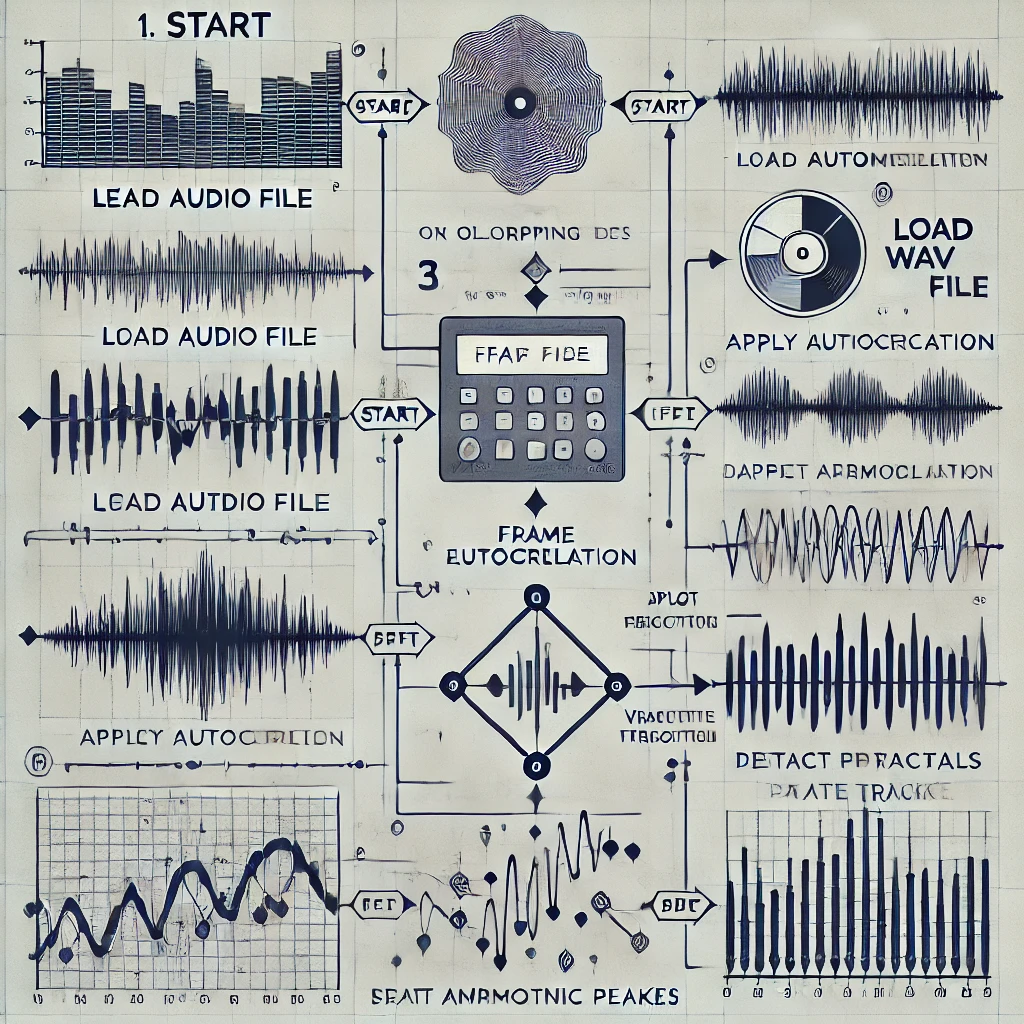

In [2]:
display(Image("../images/spectral_analysis/dall-e_partial_tracking.png",width=500))

<center> The partial tracking algorithm according to DALL·E. </center>

-----
 
# The Step-By-Step Algorithm

To get a better understanding of the partial tracking process, we will use a less performative, but more comprehensible version of this algorithm. 
This exercise provides the building blocks for the partial tracking, leaving some gaps to fill. These gaps are marked with the <font color='red'>'[CODE]'</font> label.

This version of the partial tracking algorithm consists of the following main steps:

- 0: Read and prepare audio data.
- 1: Create matrix with time-domain frames.
- 2: Create F0 trajectory.
- 3: Peak Picking.

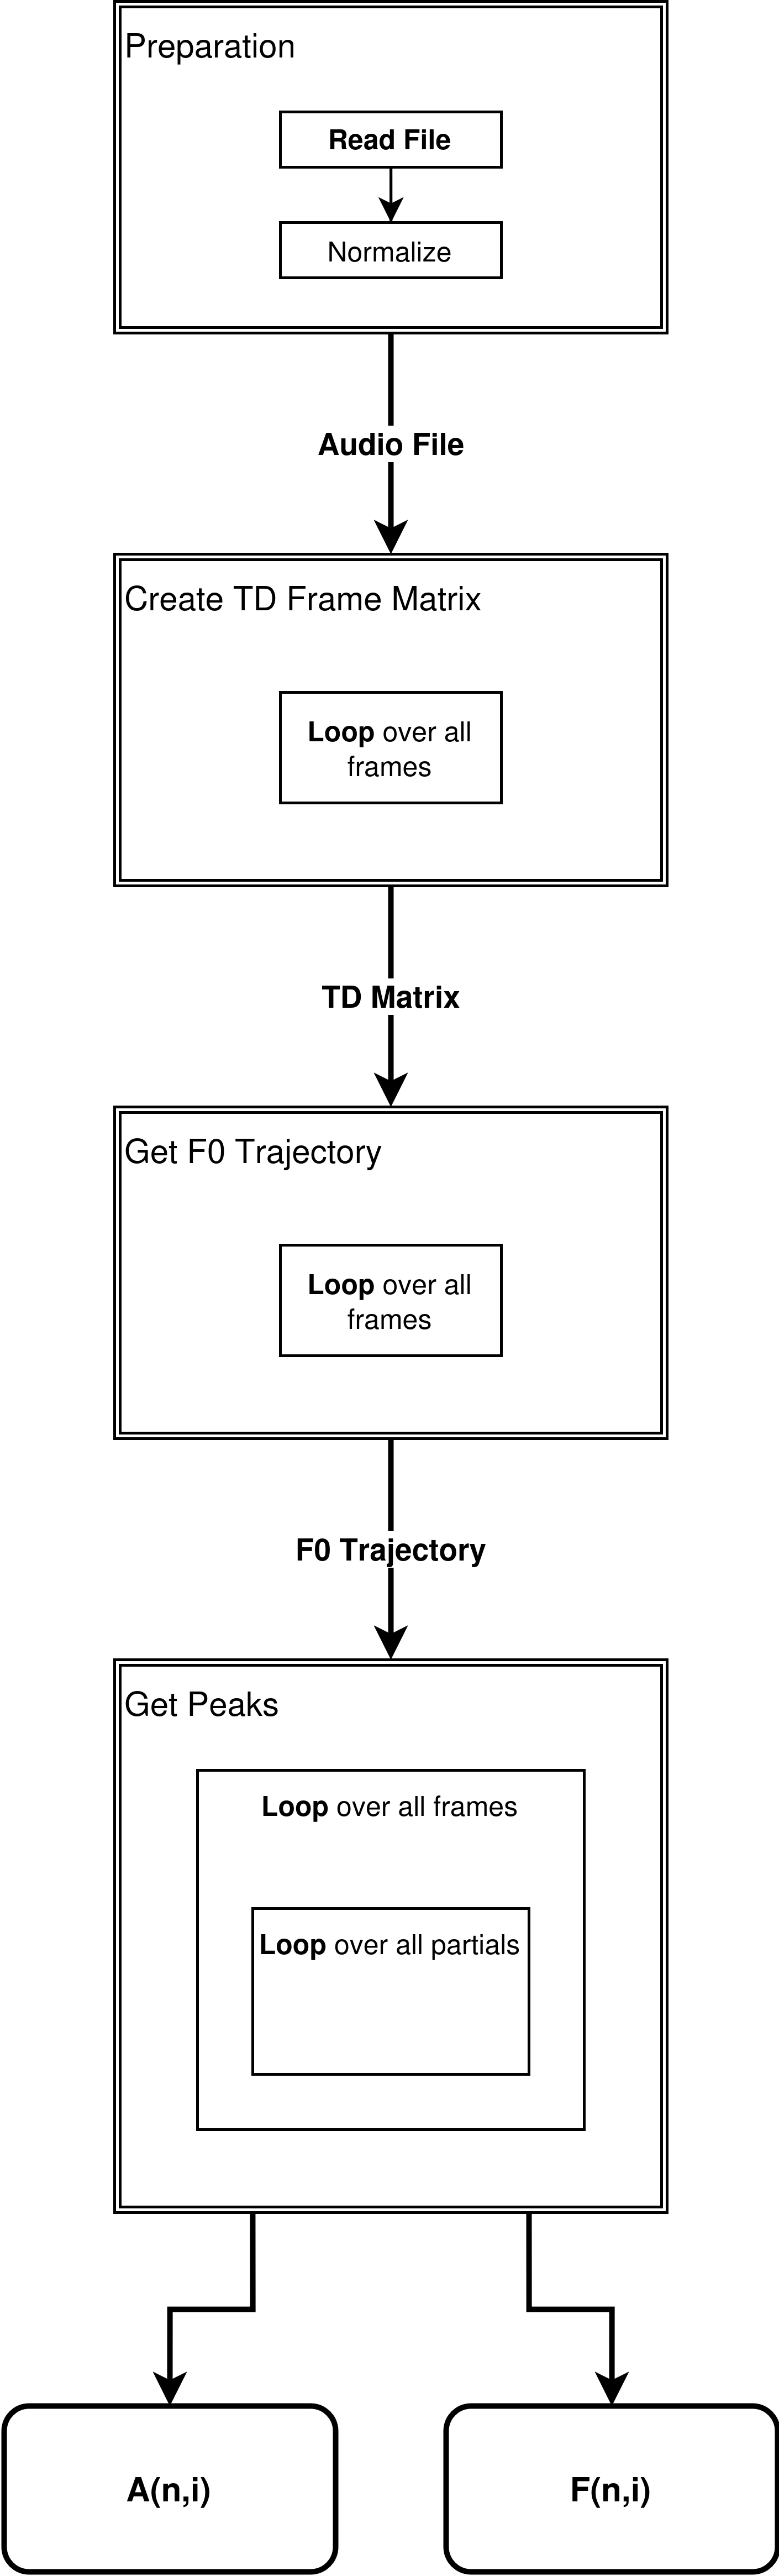

In [7]:
display(Image("../images/spectral_analysis/partial_trqacking_flow.png",width=300))



<center> Flow diagram of the partial tracking algorithm (a performance-oriented implementation would wrap all these steps into a single loop.). </center>

------

-----

# 0: Read and Prepare Audio Data

This should be no problem. 
Normalizing the audio data can help with format conversion (integer->float):

```python
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt

###########################################################################
# Read wav file
###########################################################################

fs, x = sp.io.wavfile.read('[CODE]')

# normalize audio data:
x=x/max(abs(x))
```

-----


**TU-Note Violin Sample Library**


This data-set contains monophonic violin recordings from an anechoic chamber,
creating perfect conditions for spectral modeling.
More details are available here: [https://doi.org/10.14279/depositonce-6747](https://doi.org/10.14279/depositonce-6747)


The download section of ringbuffer contains a smaller selection of items from the data-base:

- [https://ringbuffer.org/download/audio/STFT/](https://ringbuffer.org/download/audio/STFT/)
- [https://ringbuffer.org/download/audio/violin/](https://ringbuffer.org/download/audio/violin/)

It is recommended to start testing the algorithm with shorter items (SampLib) and later try how it performs with longer recordings. 

-----

# 1: Create Matrix with Time-Domain Frames

This first loop creates a matrix with all time-domain frames.
Especially when implementing such algorithms for the first time and for debugging them, this can be a great help:


```python
###########################################################################
# Frame extraction loop
###########################################################################

# length of the analysis window (samples):
nWin  = 2048*2

# hop size (samples):
nHop  = 512

# number of analysis frames that fit our signal:
N = int((len(x)-nWin)/nHop)

# allocate a matrix for the time-domain frames:
FRAMES = np.zeros([N, nWin])

# loop over all frames:
for n in range(N):

    # INFO print:
    print('Frame: '+str(n))
    # select frame:
    '[CODE]'
    # write to matrix:
    FRAMES[n,:] = frame

```


-----

# 2: Create the F0 Trajectory


We can now confortably loop over all time-domain frames and write their F0 estimates into a vector:


```python
###########################################################################
# F0 estimation loop
###########################################################################

# Define F0 search range (in Hz):
fMin = '[CODE]' 
fMax = '[CODE]' 

# Convert range to lag in autocorrelation:
minLag = int(fs/fMax)
maxLag = int(fs/fMin)

# Allocate array for the f0 trajectory:
f0vec = np.zeros(N)

# loop over all frames of the TD matrix    
for n in range(N):
    
    # get this frame
    frame = FRAMES[n,:]      
    
    # get autocorralation
    corr  = np.correlate(frame, frame, mode='full')
    corr  = corr[len(corr)//2:]  # Keep only the second half
    
    # pick peak:
    '[CODE]'    

    # Convert to Hz:
    '[CODE]'    
    
    # write to trajectory
    f0vec[n]   = pitch
    

# PLot the trajectory:
plt.plot(f0vec)
plt.ylim([0,'[CODE]'])
plt.show()
```


------


For this trajectory of a two-note sequence, we see accurate F0 estimation in the sustain of each note
and *confusion* in transients and the decay.
On zooming in, the vibrato is cleary visible:

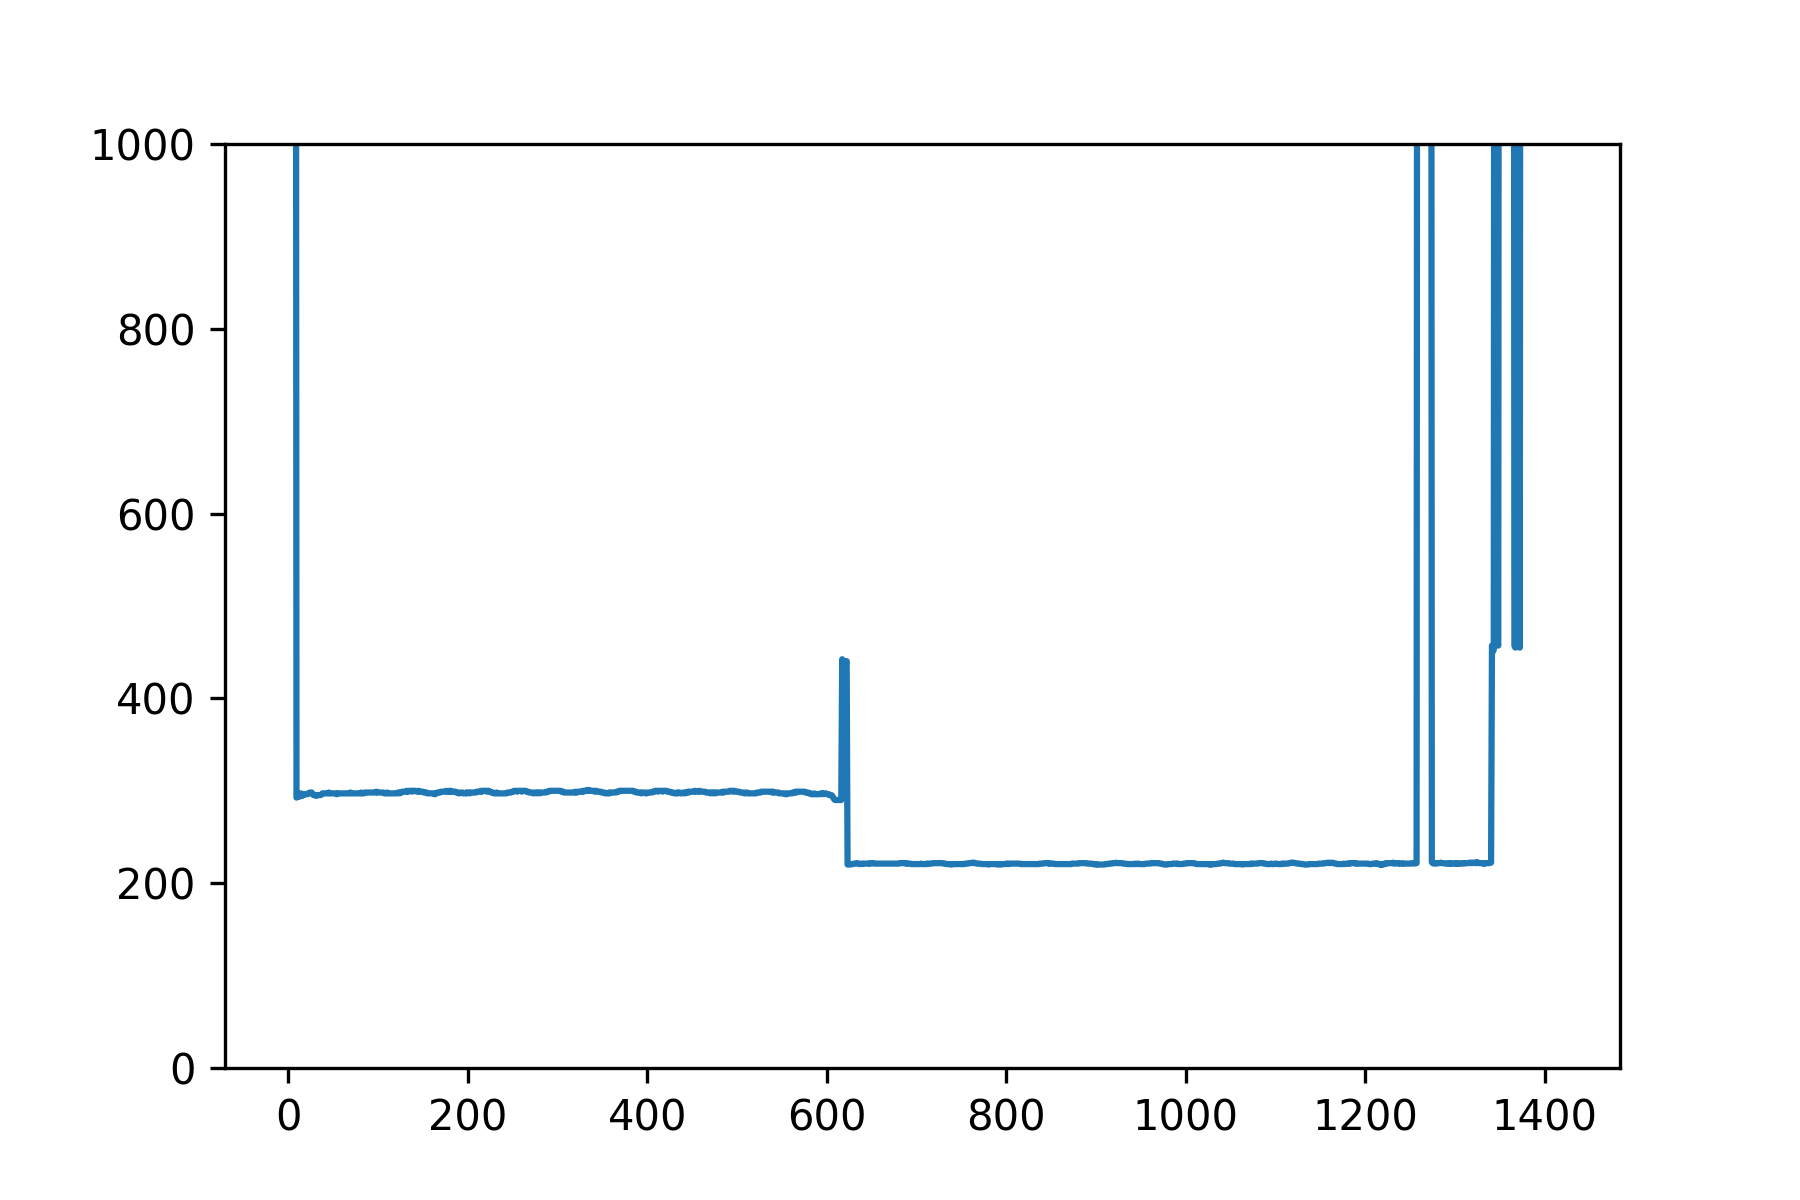

In [3]:
display(Image("../images/spectral_analysis/partial_tracking_f0.png",width=700))

-----

# 3: Peak Picking

The peak picking happens in a nested loop:

- **Loop** over all time-domain frames
    - Get FFT
    - Get F0 (from vector calculated above)
    - **Loop** over all partials:
        - Get FFT bin for partial
        - Convert to F0
        - Get peak amplitude
        - Write results into matrices


```python
###########################################################################
# Partial Tracking Loop
###########################################################################

# Define the number of partials to track:
nPart = '[CODE]'

# Create a time-domain window:
win = sp.signal.windows.hann(nWin)
    
# Allocate matrices for partial amplitudes and frequencies:
A   = np.zeros([N, nPart])
F   = np.zeros([N, nPart])

# This defines how much zero-padding is used:
nFFT = '[CODE]'

# LOOP over all time-domain frames
for n in range(N):
    
    # grab this frame and window it:
    frame = FRAMES[n,:]*win
    
    # FFT with zero padding:
    FRAME    = np.fft.fft(frame,n=nFFT) 
    
    # take abs and half spectrum:
    Fabs = abs(FRAME[0:int(nFFT/2)])

    # get this frame's F0:    
    f0   = f0vec[n]
    
    # Define a search range around the peaks:
    maxRange = '[CODE]'
    
    # LOOP over all partials:
    for i in range(nPart):
        
        # get the fft bin of this partial:
        partInd = int( (i+1) * f0 / (fs / nFFT))
        
        # if it is not out of bounds:
        if (partInd-maxRange > 0) & (partInd+maxRange <= len(Fabs)):
            
            # get this partial's amplitude:            
            a = '[CODE]'
            
            # get this partial's frequency:
            f = '[CODE]'
        
            # write values to matrices:
            A[n,i] = a            
            F[n,i] = f
        

# plot frequencies
plt.plot(F)
plt.ylim([0,5000])
plt.show()

# plot amplitudes:
plt.plot(A)
plt.show()
```

-----

We can see how the frequency estimation gets less reliable the higher the partial index.
However, the amplitude trajectories tell us that the amplitudes of higher partials are very low.
The error is caused by a low SNR for higher parials.
In a re-synthesis, this is usually not problematic, since these partials are barely audible.

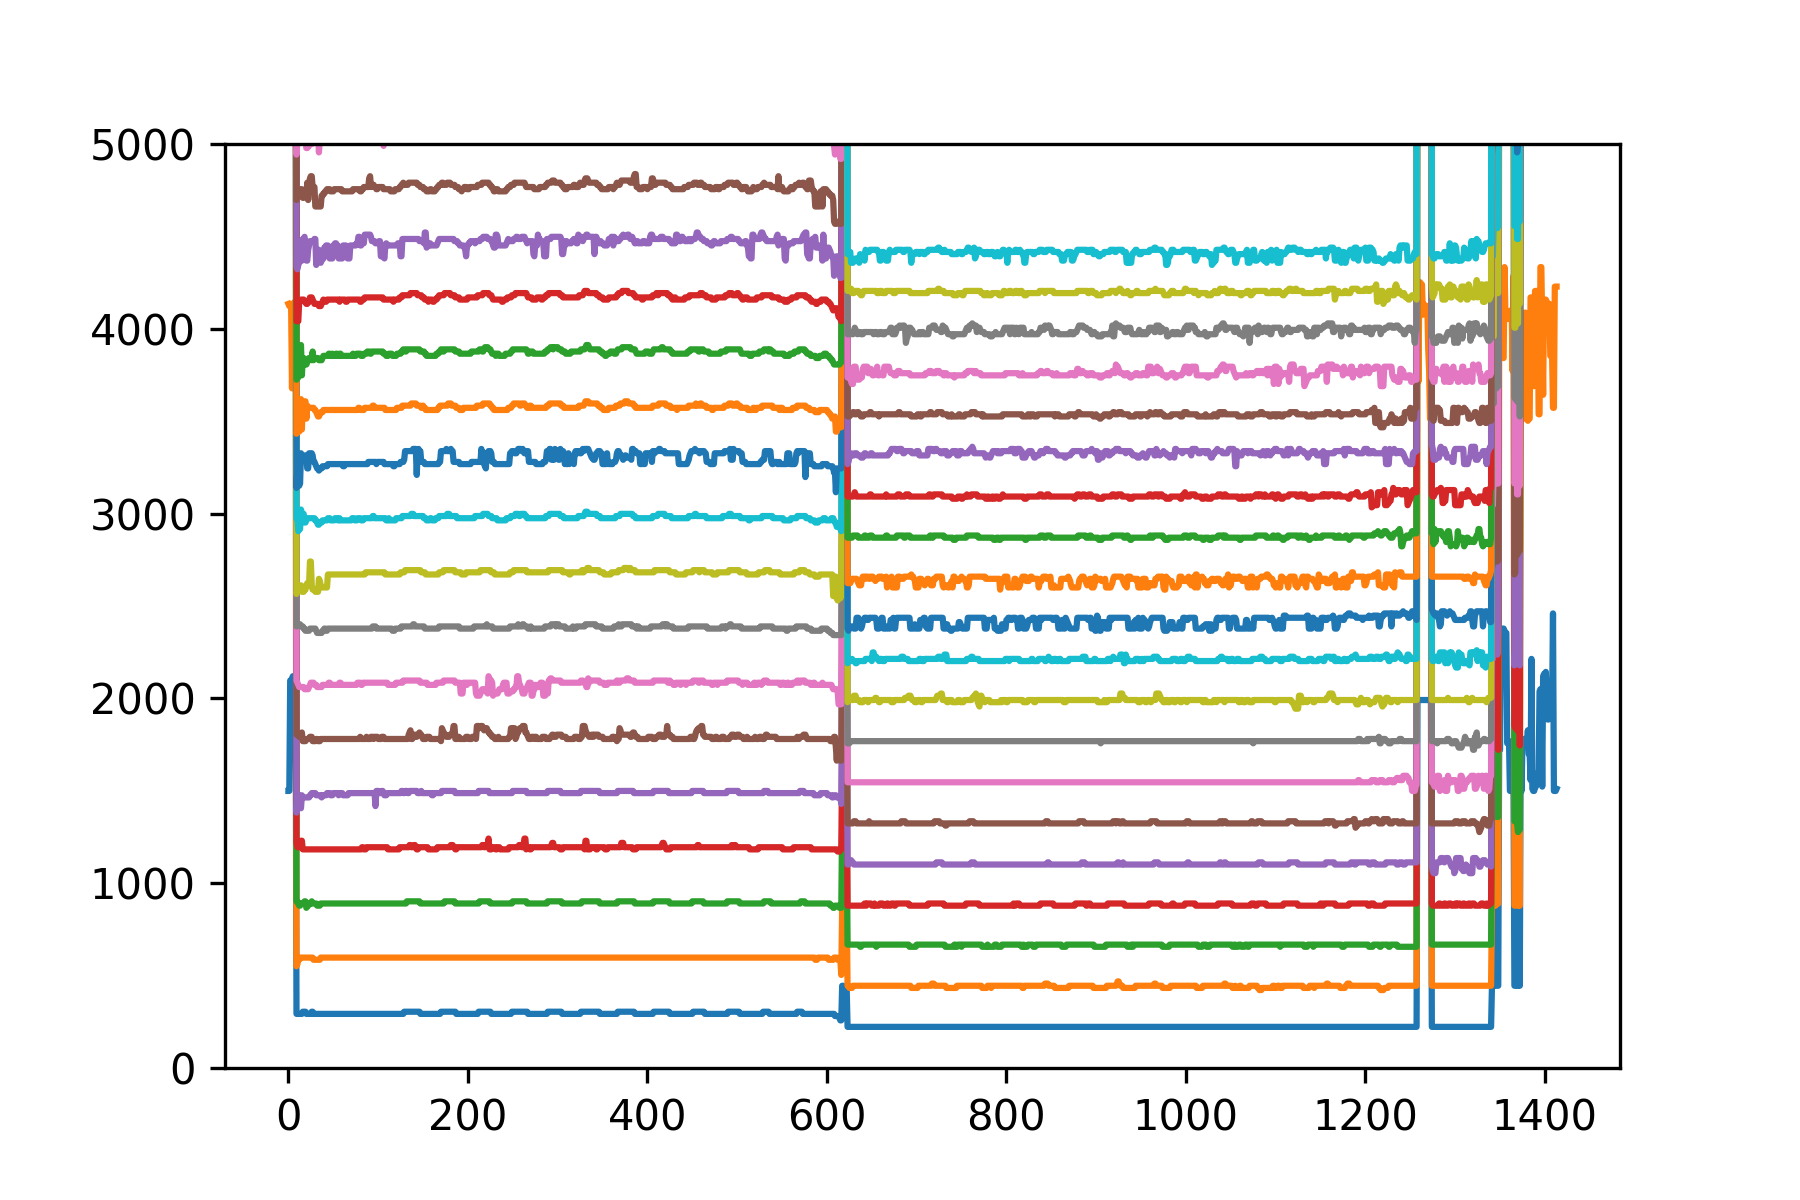

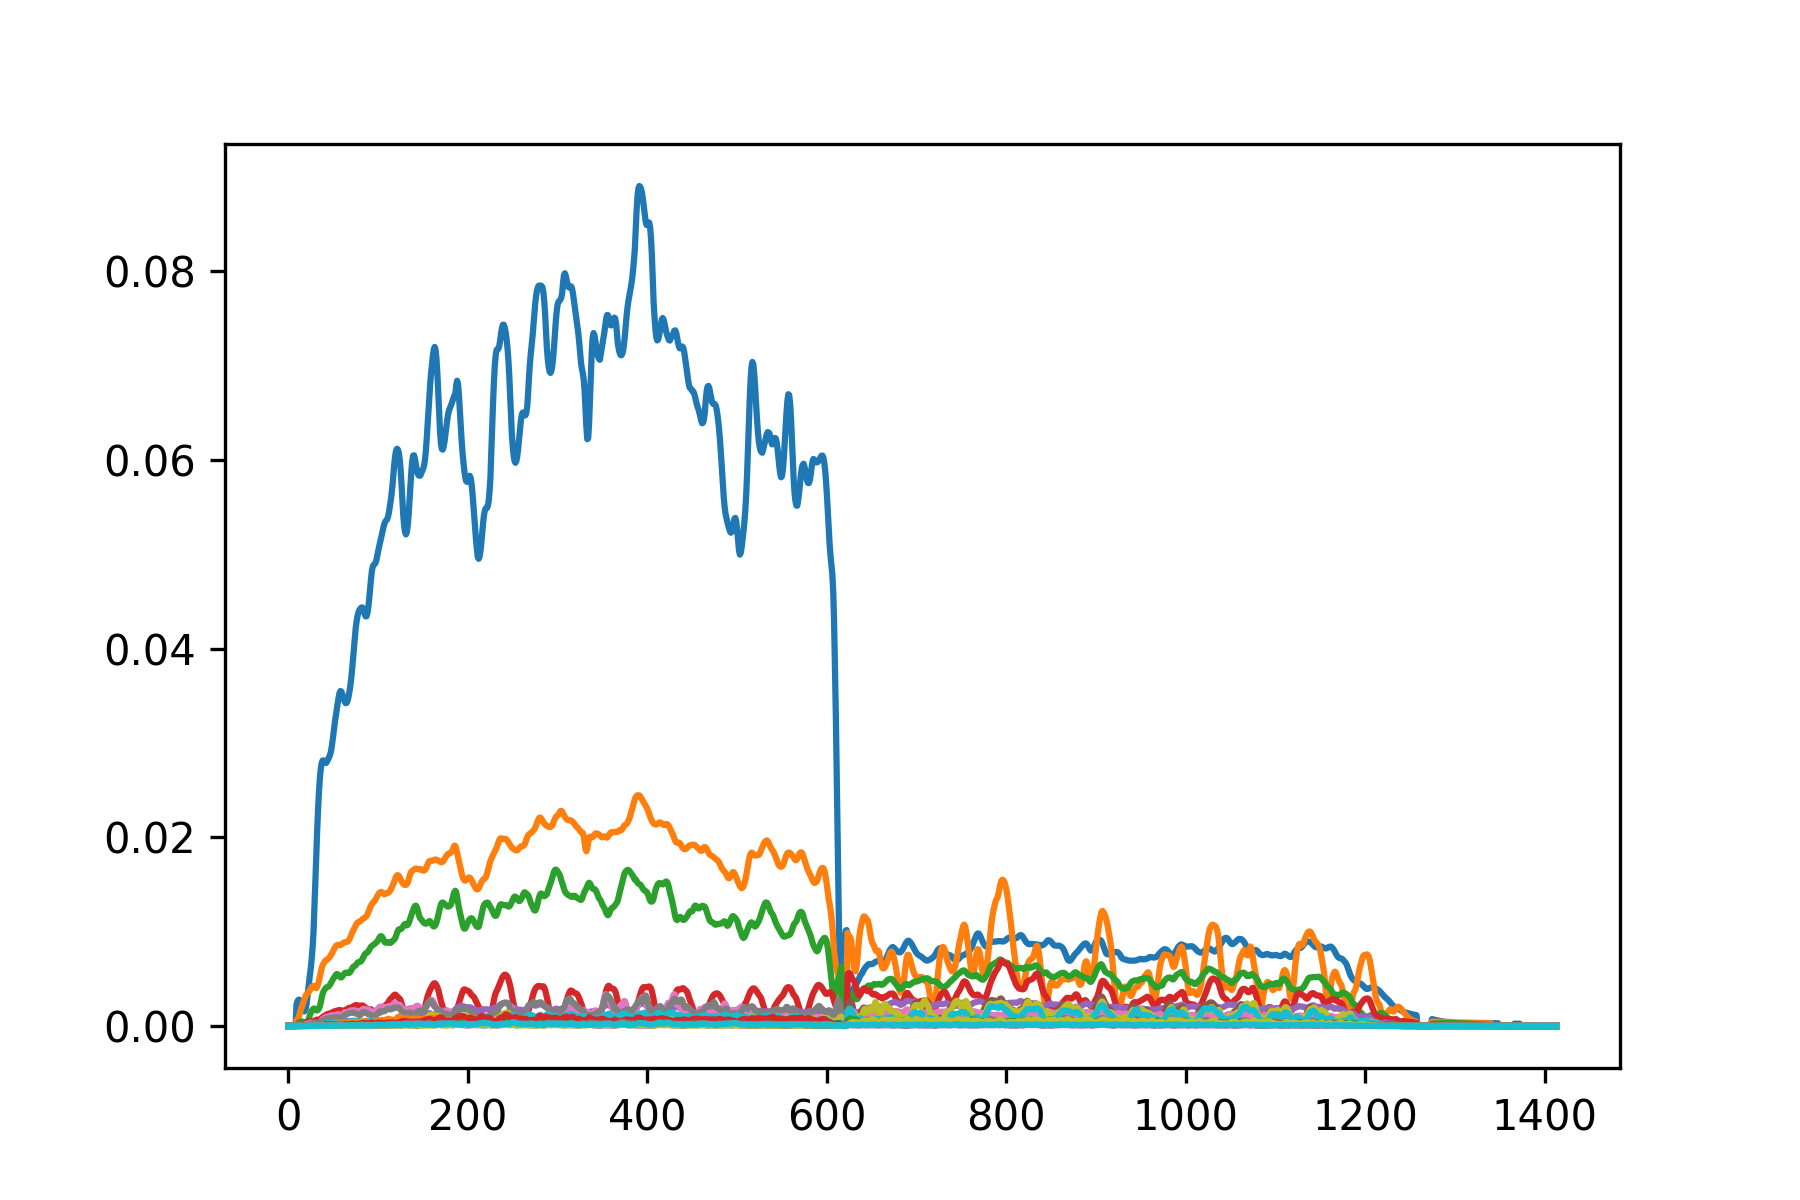

In [4]:
display(Image("../images/spectral_analysis/partial_tracking_F.png",width=700))

display(Image("../images/spectral_analysis/partial_tracking_A.png",width=700))

-----

# 4: Export Data

To make the analysis results portable, it makes sense to export them.
We can then use them for a **re-synthesis** in any software that understands our data format.
A simple way is to write the matrices with the parial frequencies and amplitudes to text files.
These can be tab-separated, comma-separated or any other format.

Numpy comes with with a *very* handy function to write arrays to text files.
The following lines create two tab-separated files with all partial trajectories.
We also export the crucial analysis parameters - the sampling rate and the hopsize - for a correct re-synthesis:

```python

###########################################################################
# Write matrices to TXT files
###########################################################################
        
np.savetxt('partial_frequencies.sms', F)
np.savetxt('partial_amplitudes.sms', A)

# write analysis parameters
np.savetxt('params.sms', [fs, nHop])
```